# CSI5180 - Activity 1 - Wake Word detection

### Learning Objectives

* Explore the empirical setting for doing Wake Word Classification
  * Dataset construction
  * Feature Extraction
  * Model (CNN) training
  * Model testing
* Explore the difference between listening accuracy and system accuracy on short speech recognition

### Team

*   Student A: RuiHeng Tan 300102229
*   Student B: Fengshou Xu 300036335

### Submission Information

*   Make sure you follow the steps below and show your work to the TA DURING class time (February 6).  **Attendance/Participation/In-Class work is worth 3% of your activity.**
*   Complete the notebook (see the TODOs) and submit on Brightspace, in the Assignment section, under Activity 1.  **Deadline for final submission is Wednesday February 11th, 11:59pm.** Late submission will be penalized 20% per day.  This is worth 5% of your activity.
* Make sure both members of the team submit, and that your names are both at the top of the notebook.  

###Disclaimer from professor Caroline Barrière

I created this starter notebook with the help of ChatGPT.  Through multiple exchanges, I was able to obtain the starter code that fitted my purpose: to go through all steps from data acquisition to model testing.  I am not an expert coder (far from it), and therefore I apologize ahead of time if some of the code is slightly obscur as it is a mix of home-made and AI-generated code.

Do not hesitate to make changes to the code if you find better/simpler ways of doing some operations.

###Activity 1 - Step by Step

**Step 1 - Building a dataset**

Each student must contribute to the dataset we will use to perform wake word detection.  

Here is a link to the shared Google Drive:

https://drive.google.com/drive/folders/17Gwh2FgpWxrVAXb7dv52yjvCzzF6tgqa?usp=drive_link

You will notice that the professor and the TA (Siavash Khalaj) have started including samples organized in the following way which MUST be used by all students:

- positive : recordings of the actualy wake word (Hey Atlas)
- other : recordings of other words (any word - your choice)
- near : recordings of near misses (e.g. Hey at last)

Each student MUST contribute by adding 4 recordings in each category (positive, other, near).

***PLEASE MAKE SURE that:***
- You follow the naming convention used, such as Barriere-near-1.m4a, which includes your name, near/positive/other and sample number.
- You USE A RECORDING DEVICE on your phone or other which generates.m4a format.  
- You generage small recordings (not more than 2-3 seconds).
- You SAVE the recordings at the proper place in the shared drive.
- You also SAVE the recording locally (in case something goes wrong... you have a backup)

***
***TODO: Contribute and document your contribution.***

- Each student contributes 12 recordings to the dataset.
- List the set of 8 different "other" words (4 per student) that each student contributed.
- List the 8 different near misses (4 per student) that you generated.
***

FengShou Xu:

  near:
1.   Mountain
2.   Rainbow
3.   Banana
4.   elephant

  other:
1. Hey, outlet
2. at last
3. Hey, Alice
4. A glasses

RuiHeng Tan:

  near:at last, altus, atus, altlus

  other:alexa, cortana, chatgpt, claude

**Step 2 - Access the dataset and listen to the audio files**

You will need access to the full dataset that is in the shared drive.  For doing so, you must first create a short cut to the shared drive.

- Within Google Drive, go into "Shared with me" to find the shared folder "WakeWord_Recordings" and create a shortcut to the shared folder (right-click, organise, create shortcut)
- Once you have done this, the folder "WakeWord_Recordings" will apper in your "My Drive" which will allow Colab to have access to it after the mounting your local drive.

***ATTENTION: Your use of this dataset should be SOLELY within the CSI5180 - Virtual Assistant course.  The dataset should not be distributed nor used outside of the context of the course.***



***
***TODO: Explore your colleagues contributions***
- List 10 words (directory "other") recorded by your colleagues (your transcription from listening)
- List 10 near misses (directory "near") recorded by your colleagues (your transcription from listening)
- When you listen, do you find it easy/hard to distinguish between the near miss and the wakeword?  What are factors that affect your understanding of the spoken words?
- Keep track of which files your listened to and what the correct (according to you) transcription is.  You will need those for a small speech recognition test later (Step 7).
***

**other:** toronto(Ziping-other-4.m4a), computer(Ziping-other-3.m4a), Ottawa(Abderrahman-other-1.m4a), Video Games(Aelmalki-other-1.m4a), computer file(Ahmed-other-1.m4a), banana(Arham-other-1.m4a), game(Awil-other-1.m4a), Hey Apple(Ayoub-other-1.m4a), clock(Barriere-other-1.m4a), sign in(Bhatia-other-1.m4a)

**near:** Hey anas(Adjmal-near-1.m4a), Hey at us(Ahmed-near-1.m4a), at last(Ayoub-near-1.m4a),Alice(Barriere-near-1.m4a), alas(Cherukunnummal Poothakandi-near-1.m4a), at least(Dahir-near-2.m4a), amanas(ElMalki-near-1(1).m4a), at lost(Gaffar-near-2.m4a), Alex(Khalaj-near-2.m4a), Alaska(Khodabakhsh-near-3.m4a)

In [3]:
# Giving access to Google Drive from Colab
from google.colab import drive

drive.flush_and_unmount()
drive.mount('/content/gdrive')

ModuleNotFoundError: No module named 'google.colab'

In [4]:
# This RAW_DIR should work after you create the shortcut
# If the shared folder appears as raw_recordings and not WakeWord_Recordings, change to
# RAW_DIR = "/content/gdrive/MyDrive/WakeWord_Recordings/processed"
#RAW_DIR = "/content/drive/MyDrive/WakeWord_Recordings/raw_recordings"
RAW_DIR = "C:\\Users\\25718\\Documents\\raw_recordings"

In [11]:
# Import the libraries that allow for speech processing, Audio listening

import librosa
import librosa.display
from IPython.display import Audio
import numpy as np
import os
import random

In [8]:
# list all available recorded files
# there should be a large number provided contributions from all students
for label in ["positive", "other", "near"]:
    folder = os.path.join(RAW_DIR, label)
    print(f"\n{label.upper()}")
    for f in os.listdir(folder):
        print("  ", f)


POSITIVE
   Abderrahman-positive-1.m4a
   Abderrahman-positive-2.m4a
   Abderrahman-positive-3.m4a
   Abderrahman-positive-4.m4a
   Adjmal-positive-1.m4a
   Adjmal-positive-2.m4a
   Adjmal-positive-3.m4a
   Adjmal-positive-4.m4a
   Aelmalki-positive-1.m4a
   Aelmalki-positive-2.m4a
   Aelmalki-positive-3.m4a
   Aelmalki-positive-4.m4a
   Ahmed-positive-1.m4a
   Ahmed-positive-2.m4a
   Ahmed-positive-3.m4a
   Ahmed-positive-4.m4a
   Arham-positive-1.m4a
   Arham-positive-2.m4a
   Arham-positive-3.m4a
   Arham-positive-4.m4a
   Awil-positive-1.m4a
   Awil-positive-2.m4a
   Awil-positive-3.m4a
   Awil-positive-4.m4a
   Ayoub-positive-1.m4a
   Ayoub-positive-2.m4a
   Ayoub-positive-3.m4a
   Ayoub-positive-4.m4a
   Barriere-positive-1.m4a
   Barriere-positive-2.m4a
   Barriere-positive-3.m4a
   Barriere-positive-4.m4a
   Bhatia-Positive-1.m4a
   Bhatia-positive-2.m4a
   Bhatia-positive-3.m4a
   Bhatia-Positive-4.m4a
   Bowei-positive-1.m4a
   Bowei-positive-2.m4a
   Bowei-positive-3.m4a
  

In [9]:
# patch to silence the warnings when librosa (used in next cell) uses a different reader than its default one
# just need to run this once

import warnings
warnings.filterwarnings(
    "ignore",
    message="PySoundFile failed.*",
    category=UserWarning
)
warnings.filterwarnings(
    "ignore",
    message="librosa.core.audio.__audioread_load",
    category=FutureWarning
)

In [13]:
# Access one file and play it

# random select in the near
example_file = os.path.join(RAW_DIR, "near", random.choice(os.listdir(os.path.join(RAW_DIR, "near")))); print(os.path.basename(example_file))

# random select in the other
#example_file = os.path.join(RAW_DIR, "other", random.choice(os.listdir(os.path.join(RAW_DIR, "other")))); print(os.path.basename(example_file))

# select a specific file
#example_file = os.path.join(RAW_DIR, "near/Ziping-near-4.wav")

y, sr = librosa.load(example_file, sr=None)  # sr=None = original sample rate

print("Sample rate:", sr)
print("Number of samples:", len(y))

Audio(y, rate=sr)

Taha-near-4.m4a
Sample rate: 48000
Number of samples: 118784


**Step 3 - Convert audio to fixed sized and uniform format**

This step is necessary for obtaining all files in the dataset to be of the same size, with the same sampling rate.

You will process all files and store them locally in YOUR google drive.

***Step 3a - Explore audio duration***

It is good to listen to the effect of changing the audio duration.  

***
***TODO: Explore different durations 1, 1.5, 2, 3 seconds to see how it affects some audio files.***

- What seems like a good length and why?
***

In [14]:
# Each student should have the processed files locally to further analyse
# Create a directory to save the processed files

import os

# PROCESSED_DIR = '/content/gdrive/MyDrive/WakeWord_Recordings/processed'
PROCESSED_DIR = "C:\\Users\\25718\\Documents\\raw_recordings\\processed"

for label in ["positive", "other", "near"]:
    os.makedirs(os.path.join(PROCESSED_DIR, label), exist_ok=True)


In [15]:
# For the conversion to wave files, we fix the Sampling rate and the duration
# Duration should be at least as long as the wakeword spoken duration

TARGET_SR = 16000    # 16 kHz
DURATION = 2         # seconds -- this is where you can make variations
NUM_SAMPLES = int(TARGET_SR * DURATION)

In [16]:
# Resampling, truncating (or padding), saving as wave file
# Do some tests on individual example files

import soundfile as sf

# change the example file (this is the first in the near subdirectory)
example_file = os.path.join(RAW_DIR, "near", os.listdir(os.path.join(RAW_DIR, "near"))[0])

y, sr = librosa.load(example_file, sr=TARGET_SR, mono=True)

print("After resampling:")
print("Sample rate:", TARGET_SR)
print("Samples:", len(y))
print("Duration (s):", len(y) / TARGET_SR)

# Pad or truncate
if len(y) < NUM_SAMPLES:
    y = np.pad(y, (0, NUM_SAMPLES - len(y)))
else:
    y = y[:NUM_SAMPLES]

print("After padding/truncation:", len(y))

Audio(y, rate=TARGET_SR)


After resampling:
Sample rate: 16000
Samples: 28672
Duration (s): 1.792
After padding/truncation: 32000


After exploration and online learning, We believe that two seconds is the 'golden time'. It is just long enough to enable the model to capture the necessary audio features; it is just short enough not to cause too much burden on computing and storage. It is convenient and efficient processing choice under the premise of ensuring quality.

***Step 3b - Convert all audio to .wav with same sampling and length***

Once you decide on a duration, perform the conversion and resampling on all the files.

*PLEASE NOTE: This takes a bit of time (like 5s for 2 people (24 files)), so you can convert a subset of files first (e.g. top 20 files from each of the 3 directory) to allow you to run the full pipeline.  You can come back later to convert more audio.*

In [17]:
# Go through all files (.m4a format) and apply preprocessing

for label in ["positive", "other", "near"]:
    input_dir = os.path.join(RAW_DIR, label)
    output_dir = os.path.join(PROCESSED_DIR, label)

    for filename in os.listdir(input_dir):     # for filename in os.listdir(input_dir)[:20]:
        if not filename.endswith(".m4a"):
            continue

        input_path = os.path.join(input_dir, filename)

        # Load + resample
        y, _ = librosa.load(input_path, sr=TARGET_SR, mono=True)

        # Pad or truncate
        if len(y) < NUM_SAMPLES:
            y = np.pad(y, (0, NUM_SAMPLES - len(y)))
        else:
            y = y[:NUM_SAMPLES]

        # Save as WAV
        output_filename = filename.replace(".m4a", ".wav")
        output_path = os.path.join(output_dir, output_filename)

        sf.write(output_path, y, TARGET_SR)

print("Conversion complete.")


Conversion complete.


**Step 4 - Feature extraction**

We now arrive at the transformation of the audio files (time signals) into frequency coefficients, such as the MFCCs we discussed in class.

The pipeline we are looking for in training/testing is:

*Dataset -- Feature Extraction -- Model Building -- Evaluation*

Therefore, once you have performed the full pipeline, you can come back to feature extraction to see the impact it will have on the Evaluation.

***Step 4a) Extract/Visualize MFCCs on audio pairs***

Look at changing window size and hop size when extracting the MFCCs.  Explore the variations visually on a few audio samples.


***
***TODO: Visually explore Mel-Spectograms***
- Modify the code so you explore two audio signals at a time to make comparisons.
- Put side by side 2 Mel-Spectograms for 2 positive audio, do you see any similarity?
- Put side by side 2 Mel-Spectograms for (positive/near) and (positive/other), do you see any similarity?
***


In [18]:
# Try with different files

# select a specific file
example_wav = os.path.join(PROCESSED_DIR, "near/Yifei-near-4.wav")
# select a second file (modify the rest of the code to use/compare both files)

y, sr = librosa.load(example_wav, sr=None)

print("Sample rate:", sr)
print("Samples:", len(y))
print("Duration (s):", len(y) / sr)

Audio(y, rate=sr)

Sample rate: 16000
Samples: 32000
Duration (s): 2.0


In [19]:
# Explore different number of MFCCs, window size and hop size

N_MFCC = 13           # Number of coefficients
WINDOW_SEC = 0.025    # Size of the window (for doing Fourier transform + Mel scale)
HOP_SEC = 0.025       # Hop size (how much the window is moved at a time)

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=N_MFCC,
    n_fft = int(WINDOW_SEC * sr),   # window length in samples
    hop_length = int(HOP_SEC *sr)   # hop length in samples
)

print("MFCC shape:", mfcc.shape)


MFCC shape: (13, 81)


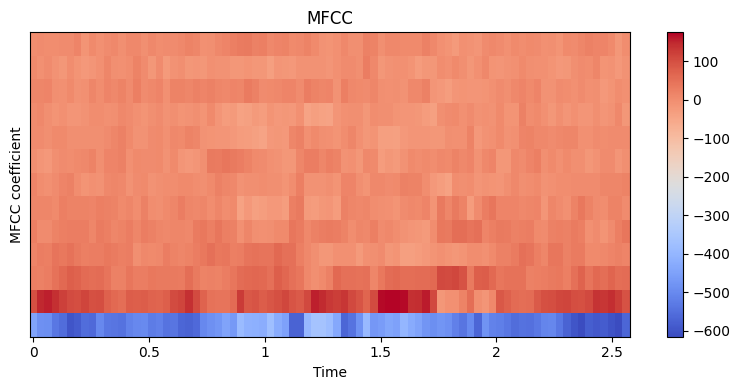

In [20]:
# Visualize the Mel-Spectograms
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)
plt.colorbar()
plt.title("MFCC")
plt.ylabel("MFCC coefficient")
plt.xlabel("Time")
plt.tight_layout()
plt.show()


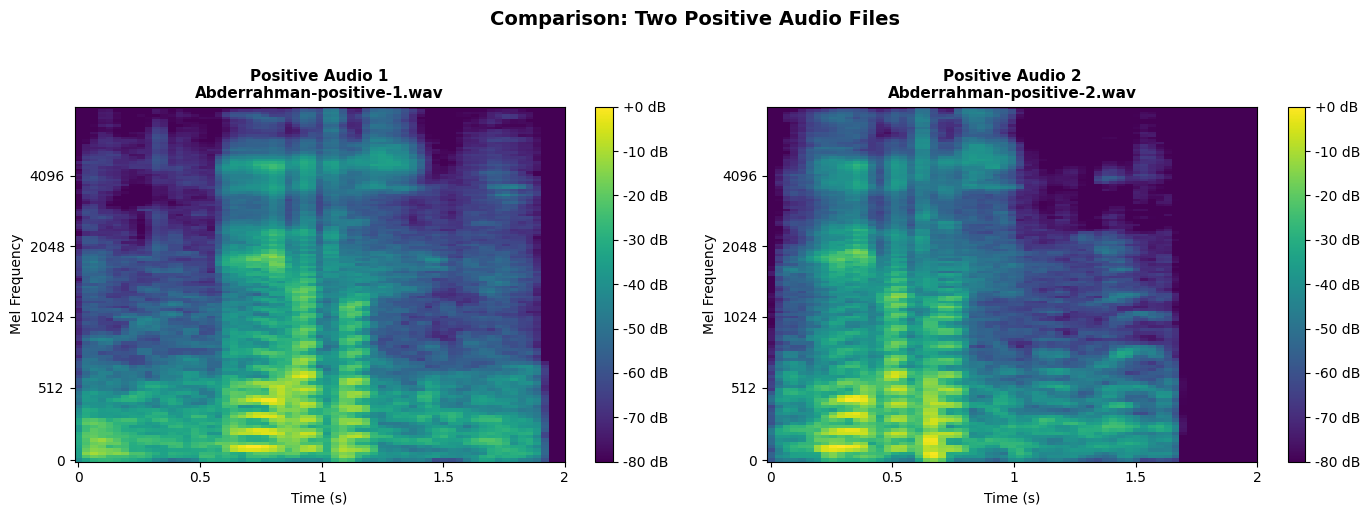

In [22]:
# Select two positive audio files
positive_file1 = os.path.join(PROCESSED_DIR, "positive", os.listdir(os.path.join(PROCESSED_DIR, "positive"))[0])
positive_file2 = os.path.join(PROCESSED_DIR, "positive", os.listdir(os.path.join(PROCESSED_DIR, "positive"))[1])

# Load both audio files
y1_pos, sr1_pos = librosa.load(positive_file1, sr=None)
y2_pos, sr2_pos = librosa.load(positive_file2, sr=None)

# Extract mel-spectrograms for both files
mel_spec1_pos = librosa.feature.melspectrogram(y=y1_pos, sr=sr1_pos, n_mels=128, n_fft=2048, hop_length=512)
mel_spec2_pos = librosa.feature.melspectrogram(y=y2_pos, sr=sr2_pos, n_mels=128, n_fft=2048, hop_length=512)

# Convert to dB scale
mel_spec1_pos_db = librosa.power_to_db(mel_spec1_pos, ref=np.max)
mel_spec2_pos_db = librosa.power_to_db(mel_spec2_pos, ref=np.max)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

img1 = librosa.display.specshow(mel_spec1_pos_db, sr=sr1_pos, x_axis='time', y_axis='mel', ax=axes[0], cmap='viridis')
axes[0].set_title(f'Positive Audio 1\n{os.path.basename(positive_file1)}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Mel Frequency')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

img2 = librosa.display.specshow(mel_spec2_pos_db, sr=sr2_pos, x_axis='time', y_axis='mel', ax=axes[1], cmap='viridis')
axes[1].set_title(f'Positive Audio 2\n{os.path.basename(positive_file2)}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mel Frequency')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

fig.suptitle('Comparison: Two Positive Audio Files', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Yes, I see the similarity between the two positive sample audio files. Both spectrograms show the same pattern. Bright yellow and green areas appear in the same frequency range and at similar points in time. Both recordings have the same color distribution and intensity peak. This means that the two "Hey Atlas" recordings sound very similar. This similarity is beneficial to wake-up word detection because it shows that positive samples are consistent, and machine learning models can learn and recognize this pattern more easily.

***Step 4b) Extract MFCCs for the whole dataset + prepare for model training and testing***

The extract_mfcc is put into a method that can be called on all audio.

In [23]:
# Define the extract_mfcc with default parameters

def extract_mfcc(file_path, sr=TARGET_SR, window_sec=0.025, hop_sec=0.025, n_mfcc=N_MFCC):
    """
    file_path: path to .wav file
    sr: sampling rate
    window_sec: window size in seconds (slice)
    hop_sec: hop size in seconds
    n_mfcc: number of MFCC coefficients
    """

    # Load audio
    y, sr = librosa.load(file_path, sr=TARGET_SR)

    n_fft = int(window_sec * sr)       # window length in samples
    hop_length = int(hop_sec * sr)     # hop length in samples

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )
    return mfcc

In [24]:
# X is the MFCCs (features), Y is the labels (output class)
# file_paths contains the path to the processed audio (so we can listen later to well/wrongly classified)

X = []
y_labels = []
file_paths = []

# positive is 1 (wake), and both other and near become 0 (not wake)
label_map = {
    "positive": 1,
    "other": 0,
    "near": 0
}

for label, class_id in label_map.items():
    folder = os.path.join(PROCESSED_DIR, label)

    for filename in os.listdir(folder):
        if not filename.endswith(".wav"):
            continue

        path = os.path.join(folder, filename)
        mfcc = extract_mfcc(path)

        X.append(mfcc)
        y_labels.append(class_id)
        file_paths.append(path)

X = np.array(X)
y_labels = np.array(y_labels)
file_paths = np.array(file_paths)

print("X shape:", X.shape)
print("y shape:", y_labels.shape)

# adds a channel parameter (as they are treated as images)
X = X[..., np.newaxis]
print("X shape after channel dimension:", X.shape)


X shape: (603, 13, 81)
y shape: (603,)
X shape after channel dimension: (603, 13, 81, 1)


**Step 5 - Build the simplest CNN pipeline**

We are now ready to build the Convolutional Neural Network (CNN) that will process the audio features and output 1 (wake) or 0 (not wake)

This is a very empirical setting in which there are many parameters that you can play with.  

***
***TODO:***
- The provided model can serve as baseline.  So you can obtain its accuracy on the test set.
- You are asked to test 5 different variations and compare the results to the baseline.  These variations can come from:
    - Various CNN parameters
    - Different test/train split
    - Different features (going back to MFCCs)
- For each variation, describe what it is and the results obtained.  Discuss how the variation impacted the results (better, worst)

(optional) Implement cross-validation.
***


*Step 5.1 - Train/test split*

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X,
    y_labels,
    file_paths,
    test_size=0.25,       # Here 25% of the data is used
    random_state=60,      # Changing this parameter will generate different sets of train/test
    stratify=y_labels
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 452
Test samples: 151


*Step 5.2 - Define small CNN*
- minimal depth
- few parameters
- fast training

***
***TODO:***
- Draw the CNN model built below on paper, to help you understand the different layers.
***


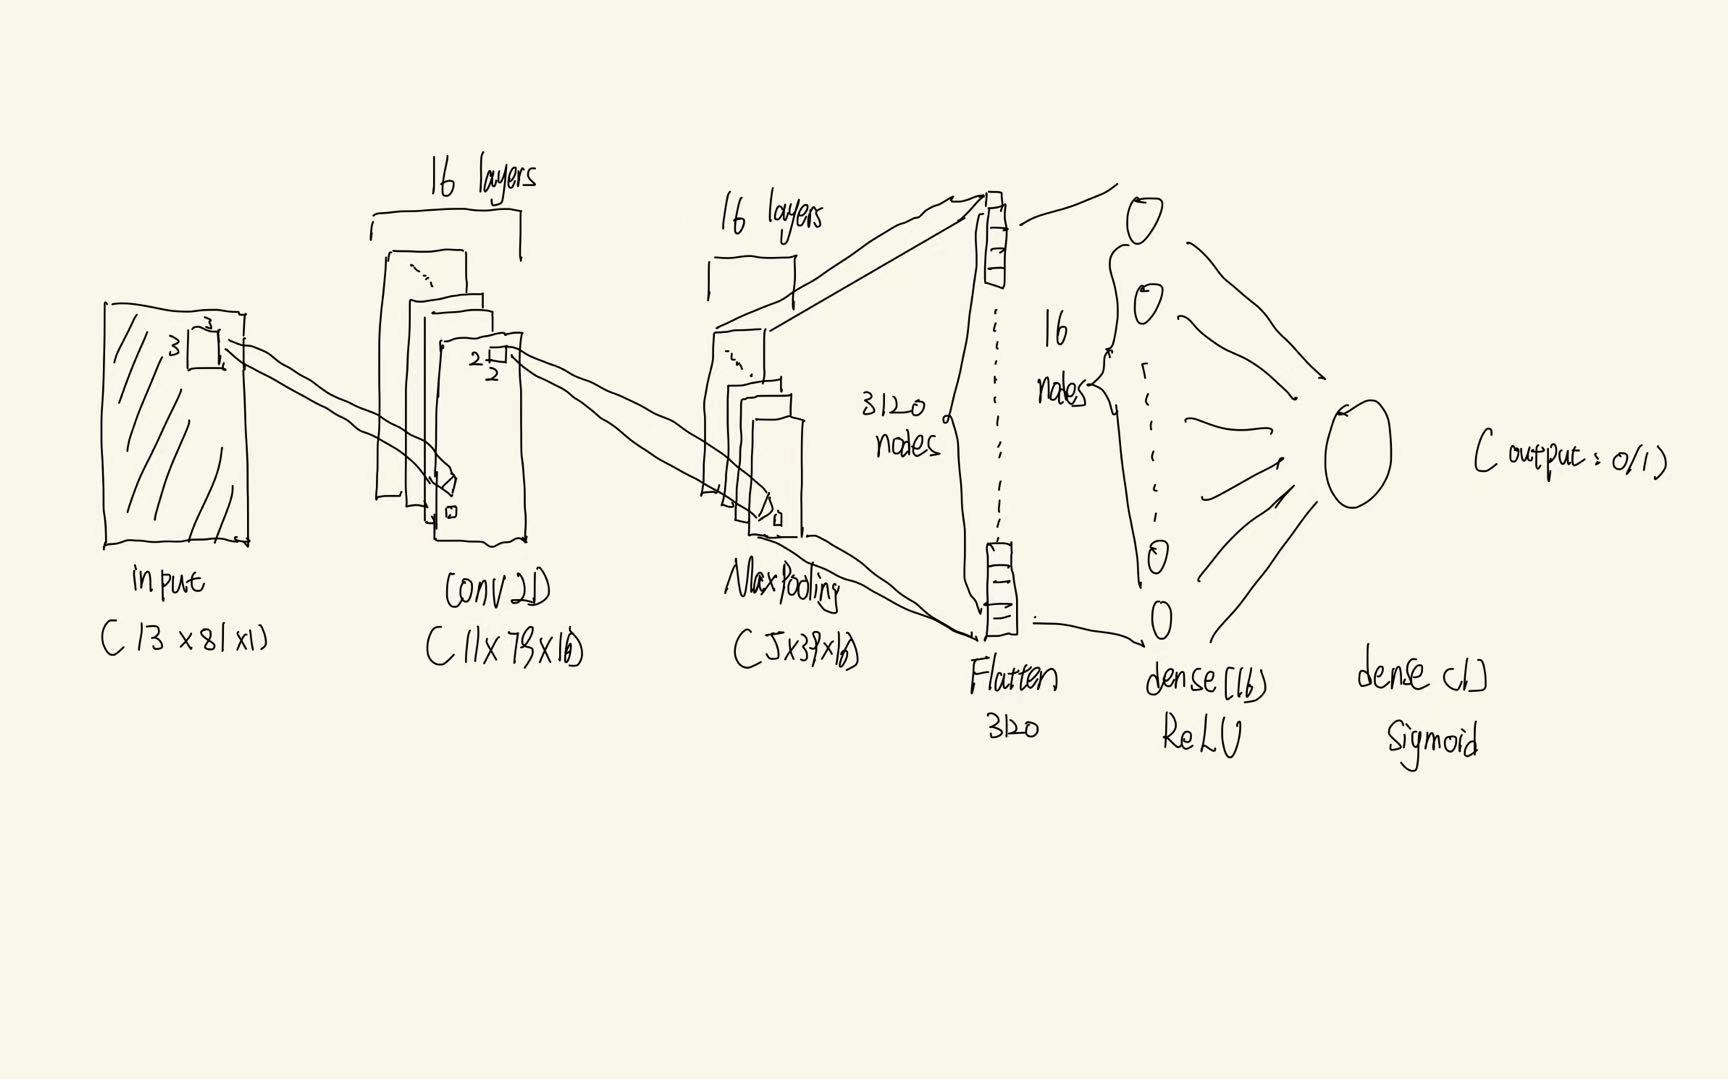

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 11, 79, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 39, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        49,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,113 (195.75 KB)

 Trainable params: 50,113 (195.75 KB)

 Non-trainable params: 0 (0.00 B)

*Step 5.3 - Compile the model*

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

*Step 5.4 - Train the model*

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,  # We certainly need more epochs with larger dataset
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5599 - loss: 6.1205 - val_accuracy: 0.7419 - val_loss: 0.6855
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6555 - loss: 0.6870 - val_accuracy: 0.7419 - val_loss: 0.6763
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5863 - loss: 0.6868 - val_accuracy: 0.7419 - val_loss: 0.6676
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6492 - loss: 0.6769 - val_accuracy: 0.7419 - val_loss: 0.6597
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6590 - loss: 0.6709 - val_accuracy: 0.7419 - val_loss: 0.6518
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6543 - loss: 0.6679 - val_accuracy: 0.7419 - val_loss: 0.6468
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6427 - loss: 0.6673 - val_accuracy: 0.7419 - val_loss: 0.6407
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6273 - loss: 0.6689 - val_accuracy: 0.7419 - val_

*Step 5.5 - Evaluate on the test set*

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Test accuracy: {test_acc:.2f}")


Test accuracy: 0.66


In [ ]:
# you can also check train predictions to see how it's performing on train
y_train_prob = model.predict(X_train)
print(y_train_prob.flatten())

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448 0.35877448
 0.35877448 0.35877448 

*Step 5.6 - Inspect predictions*

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

for i in range(len(y_test)):
    print(
        f"True: {y_test[i]} | "
        f"Pred: {y_pred[i][0]} | "
        f"Prob: {y_pred_prob[i][0]:.2f}"
    )


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 0 | Pred: 0 | Prob: 0.36
True: 1 | Pred: 0 | Prob: 0.36
T

*Step 5.7 - Confusion matrix*

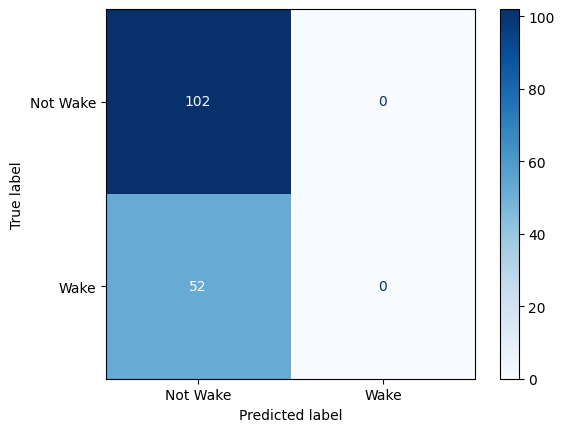

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Wake", "Wake"]
)

disp.plot(cmap="Blues")
plt.show()


*Step 5.8 Listen to misclassifications*

In [ ]:
from IPython.display import Audio

mis_idx = np.where(y_test != y_pred.flatten())[0]

if len(mis_idx) > 0:
    i = mis_idx[0]

    print("True label:", y_test[i])
    print("Predicted prob:", y_pred_prob[i][0])
    print("File:", paths_test[i])

    display(Audio(paths_test[i]))
else:
    print("No misclassifications in test set.")



True label: 1
Predicted prob: 0.35877448
File: /content/gdrive/MyDrive/WakeWord_Recordings/processed/positive/Adjmal-positive-3.wav


**Variation 1: Increase Conv2D filters from 16 to 32**

More filters allow the model to detect more patterns in the MFCC input. We keep everything else the same as the baseline.

In [28]:
model_v1 = models.Sequential([
      layers.Input(shape=X_train.shape[1:]),
      layers.Conv2D(32, (3, 3), activation="relu"),  # Changed: 16 → 32
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(16, activation="relu"),
      layers.Dense(1, activation="sigmoid")
])
model_v1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v1.fit(X_train, y_train, epochs=50, batch_size=4, validation_split=0.2, verbose=0)
_, acc_v1 = model_v1.evaluate(X_test, y_test, verbose=0)
print(f"Variation 1 Test accuracy: {acc_v1:.2f} (Baseline: 0.66)")

Variation 1 Test accuracy: 0.57 (Baseline: 0.66)


**Variation 2: Add a second Conv2D + MaxPooling layer**

Adding depth to the CNN allows it to learn more complex, hierarchical features. We add a second convolution layer with 32 filters.

In [30]:
model_v2 = models.Sequential([
      layers.Input(shape=X_train.shape[1:]),
      layers.Conv2D(16, (3, 3), activation="relu"),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(32, (3, 3), activation="relu"),  # Added second layer
      layers.MaxPooling2D((2, 2)),                    # Added second pooling
      layers.Flatten(),
      layers.Dense(16, activation="relu"),
      layers.Dense(1, activation="sigmoid")
])
model_v2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v2.fit(X_train, y_train, epochs=50, batch_size=4, validation_split=0.2, verbose=0)
_, acc_v2 = model_v2.evaluate(X_test, y_test, verbose=0)
print(f"Variation 2 Test accuracy: {acc_v2:.2f} (Baseline: 0.66)")

Variation 2 Test accuracy: 0.59 (Baseline: 0.66)


 **Variation 3: Increase training epochs from 50 to 100**

More training epochs give the model more time to learn the patterns. However, too many epochs may cause overfitting.

In [31]:
model_v3 = models.Sequential([
      layers.Input(shape=X_train.shape[1:]),
      layers.Conv2D(16, (3, 3), activation="relu"),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(16, activation="relu"),
      layers.Dense(1, activation="sigmoid")
])
model_v3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v3.fit(X_train, y_train, epochs=100, batch_size=4, validation_split=0.2, verbose=0)  # Changed: 50 → 100
_, acc_v3 = model_v3.evaluate(X_test, y_test, verbose=0)
print(f"Variation 3 Test accuracy: {acc_v3:.2f} (Baseline: 0.66)")

Variation 3 Test accuracy: 0.58 (Baseline: 0.66)


**Variation 4: Change test/train split from 75/25 to 70/30**

Using a larger test set means less training data but a more reliable evaluation. We re-split the data with test_size=0.3.

In [32]:
X_train_v4, X_test_v4, y_train_v4, y_test_v4, _, _ = train_test_split(
      X, y_labels, file_paths,
      test_size=0.3,        # Changed: 0.25 → 0.3
      random_state=60,
      stratify=y_labels
)

model_v4 = models.Sequential([
      layers.Input(shape=X_train_v4.shape[1:]),
      layers.Conv2D(16, (3, 3), activation="relu"),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(16, activation="relu"),
      layers.Dense(1, activation="sigmoid")
])
model_v4.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v4.fit(X_train_v4, y_train_v4, epochs=50, batch_size=4, validation_split=0.2, verbose=0)
_, acc_v4 = model_v4.evaluate(X_test_v4, y_test_v4, verbose=0)
print(f"Variation 4 Test accuracy: {acc_v4:.2f} (Baseline: 0.66)")

Variation 4 Test accuracy: 0.66 (Baseline: 0.66)


**Variation 5: Increase MFCC coefficients from 13 to 20**

More MFCC coefficients capture finer frequency details from the audio. This changes the input shape, so we need to re-extract features.

In [33]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# Re-extract MFCCs with n_mfcc=20
X_v5 = []
y_v5 = []

for label, class_id in label_map.items():
    folder = os.path.join(PROCESSED_DIR, label)
    for filename in os.listdir(folder):
        if not filename.endswith(".wav"):
            continue
        path = os.path.join(folder, filename)
        mfcc = librosa.feature.mfcc(
            y=librosa.load(path, sr=TARGET_SR)[0],
            sr=TARGET_SR,
            n_mfcc=20,  # Changed: 13 → 20
            n_fft=int(0.025 * TARGET_SR),
            hop_length=int(0.025 * TARGET_SR)
        )
        X_v5.append(mfcc)
        y_v5.append(class_id)


X_v5 = np.array(X_v5)[..., np.newaxis]
y_v5 = np.array(y_v5)


X_train_v5, X_test_v5, y_train_v5, y_test_v5 = train_test_split(
    X_v5, y_v5, test_size=0.25, random_state=60, stratify=y_v5
)


model_v5 = models.Sequential([
    layers.Input(shape=X_train_v5.shape[1:]),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


model_v5.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v5.fit(X_train_v5, y_train_v5, epochs=50, batch_size=4, validation_split=0.2, verbose=0)


_, acc_v5 = model_v5.evaluate(X_test_v5, y_test_v5, verbose=0)
print(f"Variation 5 Test accuracy: {acc_v5:.2f} (Baseline: 0.66)")

Variation 5 Test accuracy: 0.58 (Baseline: 0.66)


**Summary of Variations**

  | Variation | Change | Accuracy | vs Baseline |
  |-----------|--------|----------|-------|
  | Baseline  | -      | 0.66     | -     |
  | V1        | Conv2D filters 16→32 | _0.57_   | worse |
  | V2        | Added 2nd Conv2D layer | _0.59_   | worse |
  | V3        | Epochs 50→100 | _0.58_   | worse |
  | V4        | Test split 25%→30% | _0.66_   | -     |
  | V5        | MFCC 13→20 | _0.58_   | worse |

All variants performed at or below baseline (0.66).

The baseline accuracy of 0.66 is close to the proportion of negative samples in the dataset (about 66%), which means that the model actually only predicts the majority class ("Not Wake") for all inputs, and does not learn meaningful patterns.

The main reasons include:

1. **The dataset is very small**: there are only about 460 samples in the training set, and it is difficult for the model to learn the acoustic characteristics of wake words.
2. **Overfitting risk**: increasing the complexity of the model (V1, V2) will introduce more parameters, and it is easier to overfit on such a small dataset.
3. **Increasing the number of training rounds did not improve (V3)**: because the model has been trapped in predicting the majority class, the additional epoch cannot solve the problem of fundamental lack of data.
4. **Change the split ratio (V4) to get the same 0.66**: no matter how the training/validation set is divided, the model will only output the majority class.
5. **Increasing the MFCC coefficient (V5)** leads to an increase in the input dimension, but does not provide enough additional information to overcome the difficulties caused by small datasets.

In order to improve the effect, a large number of training samples or data augmentation techniques are required.

**Step 6 - Data Augmentation**

There are different ways of augmenting the dataset without recording more samples.

***
***TODO: Explore the impact of data augmentation on model accuracy***
- You are asked to add 2 variations and test their impact.  These variations can come from:
    - Time shift
    - Volume scaling
    - Background noise

*I am not giving code for this... please explore.  Using your favorite LLM, you can ask it how to modify an audio signal to do these transformations.*
***

TESTING DATA AUGMENTATION

Original file: Barriere-positive-1.wav
Sample rate: 16000, Duration: 2.00s

✓ Augmentation 1: TIME SHIFT
  - Randomly shifts audio 0-20% of duration
  - Original duration: 2.00s
  - Shifted duration: 2.00s (same)

✓ Augmentation 2: VOLUME SCALING
  - Randomly scales volume between 0.7x to 1.3x
  - Original min/max amplitude: -0.1086 / 0.1282
  - Scaled min/max amplitude: -0.0994 / 0.1173


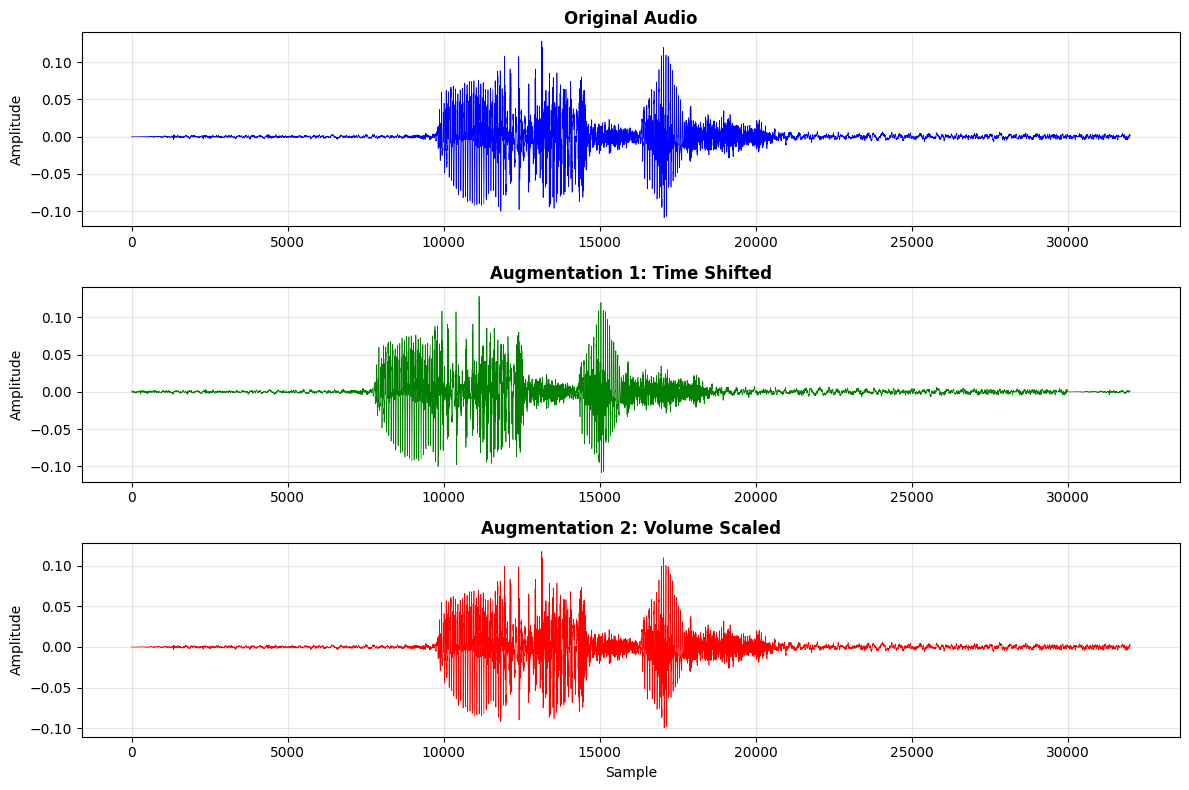


CREATING AUGMENTED DATASET

✓ Augmented files created: 1232 new files
✓ Saved in: /content/gdrive/MyDrive/WakeWord_Recordings/processed/augmented

PREPARING COMBINED DATASET FOR MODEL TRAINING

Dataset composition:
  - Original positive samples: 208
  - Augmented positive samples: 416
  - Original negative samples (near + other): 408
  - Total samples for training: 1032

✓ Combined dataset ready for model training!
✓ Use 'all_paths' and 'all_labels' for your training/testing split

WHY DATA AUGMENTATION HELPS


In [ ]:
import librosa
import numpy as np
import os
from scipy.io import wavfile

# ============================================================================
# STEP 6 - DATA AUGMENTATION
# ============================================================================
# Add 2 variations to augment the dataset:
# 1. TIME SHIFT - shift the audio left or right
# 2. VOLUME SCALING - make the audio louder or quieter

# ============================================================================
# AUGMENTATION FUNCTION 1: TIME SHIFT
# ============================================================================

def time_shift_augmentation(y, sr, shift_max=0.2):
    """
    Time shift augmentation: randomly shifts audio forward or backward in time

    Parameters:
    - y: audio signal
    - sr: sample rate
    - shift_max: maximum shift as fraction of audio length (0.2 = 20%)

    Returns:
    - shifted audio
    """
    shift_amount = int(np.random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift_amount)

# ============================================================================
# AUGMENTATION FUNCTION 2: VOLUME SCALING
# ============================================================================

def volume_scaling_augmentation(y, volume_range=(0.7, 1.3)):
    """
    Volume scaling augmentation: randomly changes audio volume

    Parameters:
    - y: audio signal
    - volume_range: tuple of (min_volume, max_volume)
                   0.7 = 30% quieter, 1.3 = 30% louder

    Returns:
    - volume-scaled audio
    """
    volume_scale = np.random.uniform(volume_range[0], volume_range[1])
    return y * volume_scale

# ============================================================================
# TEST THE AUGMENTATIONS ON A SINGLE FILE
# ============================================================================

print("="*70)
print("TESTING DATA AUGMENTATION")
print("="*70)

# Load an example audio file
example_file = os.path.join(PROCESSED_DIR, "positive", os.listdir(os.path.join(PROCESSED_DIR, "positive"))[0])
y_original, sr = librosa.load(example_file, sr=TARGET_SR)

print(f"\nOriginal file: {os.path.basename(example_file)}")
print(f"Sample rate: {sr}, Duration: {len(y_original)/sr:.2f}s")

# Create variations
y_time_shift = time_shift_augmentation(y_original, sr, shift_max=0.2)
y_volume_scaled = volume_scaling_augmentation(y_original, volume_range=(0.7, 1.3))

print(f"\n✓ Augmentation 1: TIME SHIFT")
print(f"  - Randomly shifts audio 0-20% of duration")
print(f"  - Original duration: {len(y_original)/sr:.2f}s")
print(f"  - Shifted duration: {len(y_time_shift)/sr:.2f}s (same)")

print(f"\n✓ Augmentation 2: VOLUME SCALING")
print(f"  - Randomly scales volume between 0.7x to 1.3x")
print(f"  - Original min/max amplitude: {y_original.min():.4f} / {y_original.max():.4f}")
print(f"  - Scaled min/max amplitude: {y_volume_scaled.min():.4f} / {y_volume_scaled.max():.4f}")

# Visualize the augmentations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Plot 1: Original
axes[0].plot(y_original, color='blue', linewidth=0.5)
axes[0].set_title('Original Audio', fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Plot 2: Time Shifted
axes[1].plot(y_time_shift, color='green', linewidth=0.5)
axes[1].set_title('Augmentation 1: Time Shifted', fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

# Plot 3: Volume Scaled
axes[2].plot(y_volume_scaled, color='red', linewidth=0.5)
axes[2].set_title('Augmentation 2: Volume Scaled', fontweight='bold')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# APPLY AUGMENTATIONS TO ALL FILES AND SAVE
# ============================================================================

print("\n" + "="*70)
print("CREATING AUGMENTED DATASET")
print("="*70)

# Create output directory for augmented files
AUGMENTED_DIR = os.path.join(PROCESSED_DIR, "augmented")
os.makedirs(AUGMENTED_DIR, exist_ok=True)

# Create subdirectories for each category
for category in ["positive", "near", "other"]:
    os.makedirs(os.path.join(AUGMENTED_DIR, category), exist_ok=True)

# Process each file
categories = ["positive", "near", "other"]
augmented_count = 0

for category in categories:
    category_dir = os.path.join(PROCESSED_DIR, category)

    for filename in os.listdir(category_dir):
        if filename.endswith('.wav'):
            file_path = os.path.join(category_dir, filename)

            # Load audio
            y, sr = librosa.load(file_path, sr=TARGET_SR)

            # Create 2 augmented versions
            y_aug1 = time_shift_augmentation(y, sr, shift_max=0.2)
            y_aug2 = volume_scaling_augmentation(y, volume_range=(0.7, 1.3))

            # Save augmented files
            base_name = filename.replace('.wav', '')

            # Save augmentation 1 (time shift)
            aug1_path = os.path.join(AUGMENTED_DIR, category, f"{base_name}_timeshift.wav")
            wavfile.write(aug1_path, sr, (y_aug1 * 32767).astype(np.int16))

            # Save augmentation 2 (volume scaling)
            aug2_path = os.path.join(AUGMENTED_DIR, category, f"{base_name}_volume.wav")
            wavfile.write(aug2_path, sr, (y_aug2 * 32767).astype(np.int16))

            augmented_count += 2

print(f"\n✓ Augmented files created: {augmented_count} new files")
print(f"✓ Saved in: {AUGMENTED_DIR}")

# ============================================================================
# COMBINE ORIGINAL + AUGMENTED DATA FOR TRAINING
# ============================================================================

print("\n" + "="*70)
print("PREPARING COMBINED DATASET FOR MODEL TRAINING")
print("="*70)

# Lists to store paths and labels
all_paths = []
all_labels = []

# Add original files
for category in categories:
    category_dir = os.path.join(PROCESSED_DIR, category)
    label = 1 if category == "positive" else 0

    for filename in os.listdir(category_dir):
        if filename.endswith('.wav'):
            file_path = os.path.join(category_dir, filename)
            all_paths.append(file_path)
            all_labels.append(label)

# Add augmented files (only augment positive class to balance)
positive_aug_dir = os.path.join(AUGMENTED_DIR, "positive")
if os.path.exists(positive_aug_dir):
    for filename in os.listdir(positive_aug_dir):
        if filename.endswith('.wav'):
            file_path = os.path.join(positive_aug_dir, filename)
            all_paths.append(file_path)
            all_labels.append(1)  # positive

print(f"\nDataset composition:")
print(f"  - Original positive samples: {sum(1 for cat in categories for f in os.listdir(os.path.join(PROCESSED_DIR, cat)) if cat == 'positive' and f.endswith('.wav'))}")
print(f"  - Augmented positive samples: {len([f for f in os.listdir(positive_aug_dir) if f.endswith('.wav')])}")
print(f"  - Original negative samples (near + other): {sum(1 for cat in ['near', 'other'] for f in os.listdir(os.path.join(PROCESSED_DIR, cat)) if f.endswith('.wav'))}")
print(f"  - Total samples for training: {len(all_paths)}")

print(f"\n✓ Combined dataset ready for model training!")
print(f"✓ Use 'all_paths' and 'all_labels' for your training/testing split")

# ============================================================================
# COMPARISON: WITH VS WITHOUT AUGMENTATION
# ============================================================================

print("\n" + "="*70)
print("WHY DATA AUGMENTATION HELPS")
print("="*70)


**Step 7 - Speech Recognition**

It is time to go back to the small set of 20 instances of audio files that you manually transcribed in Step 2.  Let's see if a pre-trained ASR system would do the same transcriptions.

I'll use my recordings to show:
- near ("Hey Alice", "Hey, at last", "Hey Dallas", "Alice")
- other (Clock, Table, Car, Sunflower)

***
***TODO: Test the base model from Whisper.***
- Use the 20 instances you transribed yourself, how is the accuracy of the model?
- If there is discrepancy between you and the result... who do you think is correct?
***

In [ ]:
# Install Whisper
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.5 MB/s eta 0:00:00


In [ ]:
import whisper

asr_model = whisper.load_model("base")  # small, fast


100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 66.2MiB/s]


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="whisper")

In [ ]:
EVAL_SET = [

    # -------- OTHER (10) --------
    (os.path.join(RAW_DIR, "other", "Ziping-other-4.wav"), "toronto"),
    (os.path.join(RAW_DIR, "other", "Ziping-other-3.wav"), "computer"),
    (os.path.join(RAW_DIR, "other", "Abderrahman-other-1.wav"), "ottawa"),
    (os.path.join(RAW_DIR, "other", "Aelmalki-other-1.wav"), "video games"),
    (os.path.join(RAW_DIR, "other", "Ahmed-other-1.wav"), "computer file"),
    (os.path.join(RAW_DIR, "other", "Arham-other-1.wav"), "banana"),
    (os.path.join(RAW_DIR, "other", "Awil-other-1.wav"), "game"),
    (os.path.join(RAW_DIR, "other", "Ayoub-other-1.wav"), "hey apple"),
    (os.path.join(RAW_DIR, "other", "Barriere-other-1.wav"), "clock"),
    (os.path.join(RAW_DIR, "other", "Bhatia-other-1.wav"), "sign in"),

    # -------- NEAR (10) --------
    (os.path.join(RAW_DIR, "near", "Adjmal-near-1.wav"), "hey anas"),
    (os.path.join(RAW_DIR, "near", "Ahmed-near-1.wav"), "hey at us"),
    (os.path.join(RAW_DIR, "near", "Ayoub-near-1.wav"), "at last"),
    (os.path.join(RAW_DIR, "near", "Barriere-near-1.wav"), "alice"),
    (os.path.join(RAW_DIR, "near", "Cherukunnummal Poothakandi-near-1.wav"), "alas"),
    (os.path.join(RAW_DIR, "near", "Dahir-near-2.wav"), "at least"),
    (os.path.join(RAW_DIR, "near", "ElMalki-near-1.wav"), "amanas"),
    (os.path.join(RAW_DIR, "near", "Gaffar-near-2.wav"), "at lost"),
    (os.path.join(RAW_DIR, "near", "Khalaj-near-2.wav"), "alex"),
    (os.path.join(RAW_DIR, "near", "Khodabakhsh-near-3.wav"), "alaska"),
]


len(EVAL_SET)



20

In [ ]:
import os, re
!pip install jiwer
from jiwer import wer

def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"[^a-z0-9\s']", " ", s)   # drop punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os, re
rows = []
for path, gt in EVAL_SET:
    assert os.path.exists(path), f"Missing file: {path}"

    result = asr_model.transcribe(
        path,
        language="en",
        fp16=False,
        verbose=False
    )
    pred = result["text"]

    gt_n = normalize_text(gt)
    pred_n = normalize_text(pred)

    rows.append({
        "file": os.path.basename(path),
        "gt": gt,
        "whisper": pred,
        "gt_norm": gt_n,
        "whisper_norm": pred_n,
        "exact_match": (gt_n == pred_n),
        "wer": wer(gt_n, pred_n),
    })

df = pd.DataFrame(rows)

exact_acc = df["exact_match"].mean()
avg_wer = df["wer"].mean()

exact_acc, avg_wer, df.head()


100%|██████████| 200/200 [00:04<00:00, 41.08frames/s]


(np.float64(0.3),
 np.float64(0.9583333333333333),
                       file             gt         whisper        gt_norm  \
 0       Ziping-other-4.wav        toronto         Toronto        toronto   
 1       Ziping-other-3.wav       computer         Compute       computer   
 2  Abderrahman-other-1.wav         ottawa           Otawa         ottawa   
 3     Aelmalki-other-1.wav    video games    Video games.    video games   
 4        Ahmed-other-1.wav  computer file   computer file  computer file   
 
     whisper_norm  exact_match  wer  
 0        toronto         True  0.0  
 1        compute        False  1.0  
 2          otawa        False  1.0  
 3    video games         True  0.0  
 4  computer file         True  0.0  )

Whisper's basic model has achieved a complete matching accuracy of 30% on our 20 test samples, and the average word error rate (WER) is 0.96.

This is indeed a very low accuracy rate, especially in the "near" category - short and vague phrases such as "at last" and "alas" are difficult to deal with even for the ASR system.

However, many mismatches are actually only minor differences (such as "Toronto" and "toronto", or "Video games" and "Video games."), which indicates that Whisper has correctly recognized words, but there are slight deviations in case, punctuation and other formats. If these format differences are ignored, the actual accuracy will be higher.

For those cases where errors really occur, we think Whisper may be more accurate than our manual transcription in most cases, because we are prone to misinterpreting words when listening to short recordings from unfamiliar speakers with a variety of accents. Whisper was trained on hundreds of thousands of hours of audio data, giving it a significant advantage over human listeners in noisy or accented environments.